In [33]:
import math
import matplotlib.pyplot as plt

In [34]:
# datasets

x1 = [10,8,13,9,11,14,6,4,12,7,5]
y1 = [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68]

x2 = [10,8,13,9,11,14,6,4,12,7,5]
y2 = [9.14,8.14,8.47,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74]

x3 = [8,8,8,8,8,8,8,8,8,8,50]
y3 = [6.58,5.76,7.71,8.84,8.47,7.04,5.25,5.56,7.91,6.89,12.50]

x4 = [10.0,8.0,13.0,9.0,11.0,14.0,6.0,4.0,12.0,7.0,5.0]
y4 = [7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]

# experimento para responder a questão 4 (removendo o outlier)
x4_ = [10.0,8.0,9.0,11.0,14.0,6.0,4.0,12.0,7.0,5.0]
y4_ = [7.46,6.77,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]

datasets = [
    {
        "color": 'red',
        "points": (x1, y1),
    },
    {
        "color": 'blue',
        "points": (x2, y2),
    },
    {
        "color": 'green',
        "points": (x3, y3),
    },
    {
        "color": 'orange',
        "points": (x4, y4),
    },
    {
        "color": 'purple',
        "points": (x4_, y4_),
    }
]

In [35]:
def avg(arr):
    return sum(arr) / len(arr)

def correlacao(arr_x: list[int], arr_y: list[float]) -> float:
    avg_x = avg(arr_x)
    avg_y = avg(arr_y)

    de: float = 0.0
    dv1: float = 0.0
    dv2: float = 0.0

    for x, y in zip(arr_x, arr_y):
        de += (x - avg_x) * (y - avg_y)
        dv1 += (x - avg_x)**2
        dv2 += (y - avg_y)**2

    dv = math.sqrt(dv1 * dv2)

    r = de/dv

    return r

def regressao(x_: float, arr_x: list[int], arr_y: list[float]):
    avg_x = avg(arr_x)
    avg_y = avg(arr_y)

    b1: float = 0.0

    de: float = 0.0
    dv: float = 0.0

    for x, y in zip(arr_x, arr_y):
        de += (x - avg_x) * (y - avg_y)
        dv += (x - avg_x)**2

    b1 = de / dv

    b0 = avg_y - (b1 * avg_x)

    y = b0 + (b1 * x_)

    return b0, b1, y

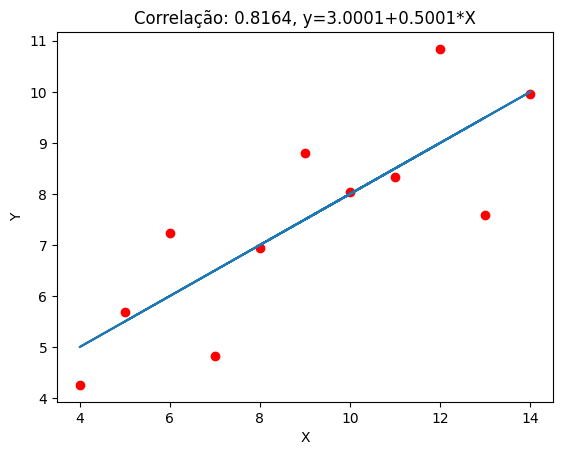

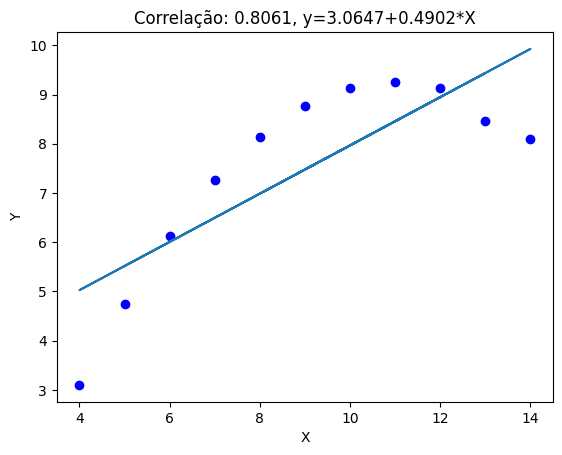

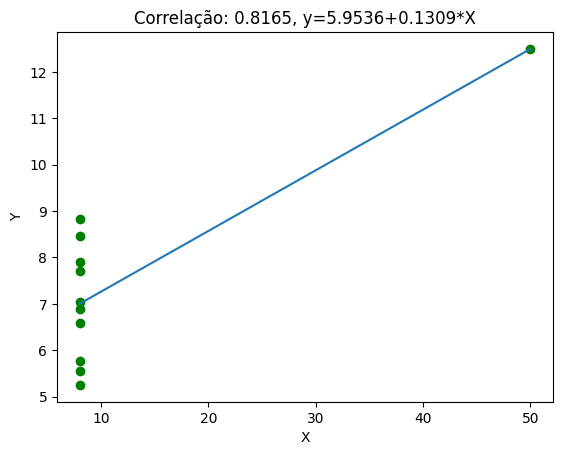

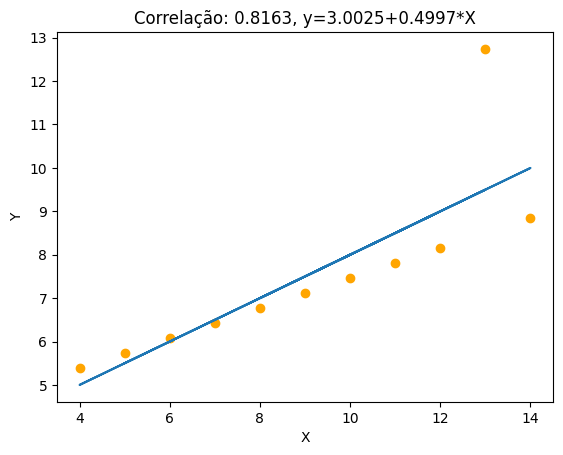

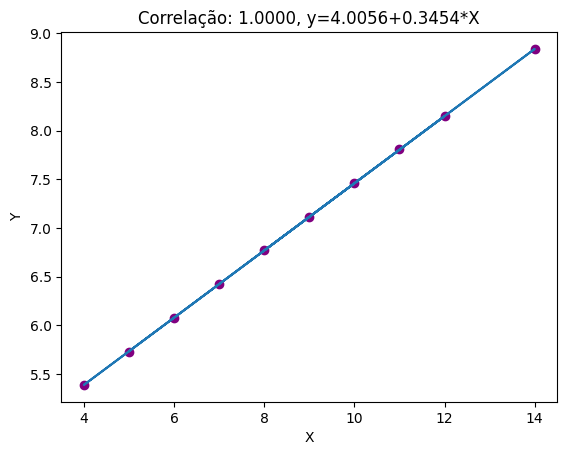

In [36]:
def demo(d):
    x = d['points'][0]
    y = d['points'][1]
    color = d['color']

    y_chapeu = []

    c = correlacao(x, y) # -1 -- 1

    for x_ in x:
        b0, b1, r = regressao(x_, x, y)
        y_chapeu.append(r)

        b0_f = "%.4f" % b0
        b1_f = "%.4f" % b1

        c_f = "%.4f" % c


        title = f"Correlação: {c_f}, y={b0_f}+{b1_f}*X"
        plt.title(title)

    plt.scatter(x, y, color=color, label='Dataset')

    plt.plot(x, y_chapeu)

    plt.xlabel("X")
    plt.ylabel("Y")

    plt.show()

for d in datasets:
    demo(d)

3. **Dataset 3**. Pois, o eixo X sempre assume 8 (valores muito concentrados), somente o último valor é a exceção (de valor 19), ou seja, independente do valor, o 8 sempre será evidente por causa do cálculo da média (que torna ele evidente). Resumindo: os dados são ruins. **Dataset 2**. O dataset 2 é um ótimo candidato para regressão polinomial, e não se aplica para regressão linear, apesar do valor de correlação ser forte.

4. Filtrar os dados do dataset, eliminando o valor outlier (fizemos um experimento no último gráfico, de cor roxa, sem o outlier, com correlação=1.00)